In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, make_scorer, accuracy_score, f1_score, r2_score, mean_absolute_error, mutual_info_score, roc_curve, zero_one_loss
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import LinearSVC, SVC
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import BaseEstimator, TransformerMixin, clone
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter, defaultdict


---
---

Text(0.5, 1.0, 'Weekly samples & defect rate')

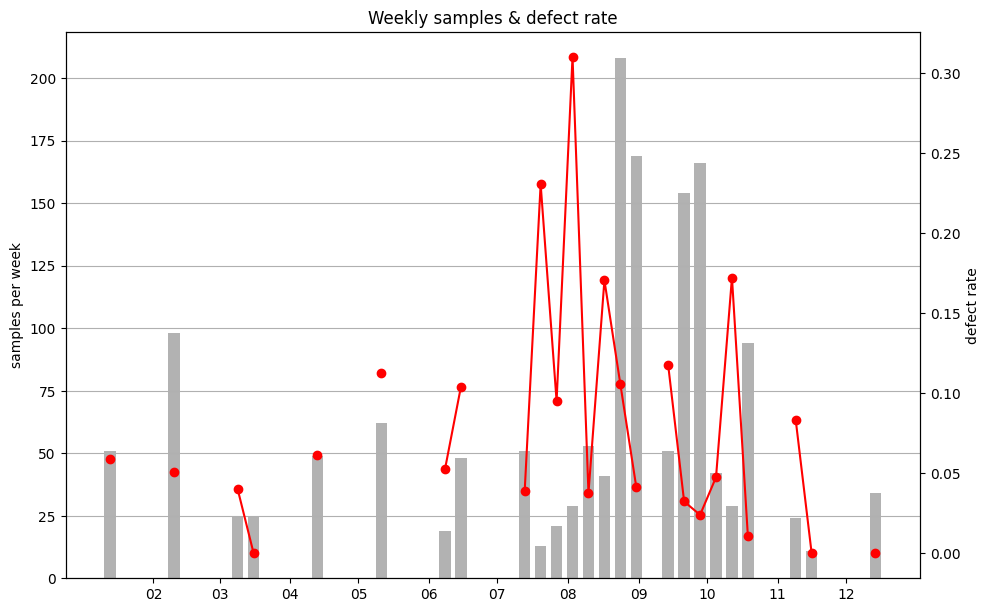

In [ ]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

time_dt = pd.to_datetime(secom['Time'])
df = pd.DataFrame({'Time':time_dt, 'y':y}).sort_values('Time').set_index('Time')

w = df['y'].resample('W') # W means the end of the date
cnt, rate = w.size(), w.mean() # rate means 1/0 (fail/pass) less is better

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(cnt.index, cnt.values, width=5, alpha=0.3, color='k')
ax1.set_ylabel('samples per week')
ax1.grid(True, axis='y')

ax2 = ax1.twinx()
ax2.plot(rate.index, rate.values, marker='o', color='r')
ax2.set_ylabel('defect ratio')
months = pd.date_range(rate.index.min().normalize(),
                       rate.index.max().normalize(), freq='MS') 
ax2.set_xticks(months)
ax2.set_xticklabels([d.strftime('%m') for d in months], rotation=0, ha='center')

plt.tight_layout()
plt.title('Weekly samples & defect ratio')


---
---

### 所有機器學習模型的10折結果, 作缺值, 相關性特徵選擇, 中位數補值
| Model              |   ACC  |   FAR  | Sensitivity | Specificity |   GM   |
| :----------------- | :----: | :----: | :---------: | :---------: | :----: |
| **RandomForest**   | 0.9066 | 0.0410 |    0.1708   |    0.9590   | 0.3497 |
| **XGBoost**        | 0.9282 | 0.0103 |    0.0583   |    0.9897   | 0.1296 |
| **SVC**            | 0.9266 | 0.0111 |    0.0486   |    0.9889   | 0.1187 |
| **DecisionTree**   | 0.7925 | 0.1718 |    0.2917   |    0.8282   | 0.4733 |
| **Lasso-Logistic** | 0.8484 | 0.1145 |    0.3250   |    0.8855   | 0.4652 |
| **LinearReg**      | 0.8061 | 0.1607 |    0.3389   |    0.8393   | 0.5092 |

[RandomForest] MEAN acc=0.9066 FAR=0.0410 sens=0.1708 spec=0.9590 GM=0.3497
[XGBoost] MEAN acc=0.9282 FAR=0.0103 sens=0.0583 spec=0.9897 GM=0.1296
[SVC] MEAN acc=0.9266 FAR=0.0111 sens=0.0486 spec=0.9889 GM=0.1187
[DecisionTree] MEAN acc=0.7925 FAR=0.1718 sens=0.2917 spec=0.8282 GM=0.4733
[Lasso-Logistic] MEAN acc=0.8484 FAR=0.1145 sens=0.3250 spec=0.8855 GM=0.4652
[LinearReg] MEAN acc=0.8061 FAR=0.1607 sens=0.3389 spec=0.8393 GM=0.5092


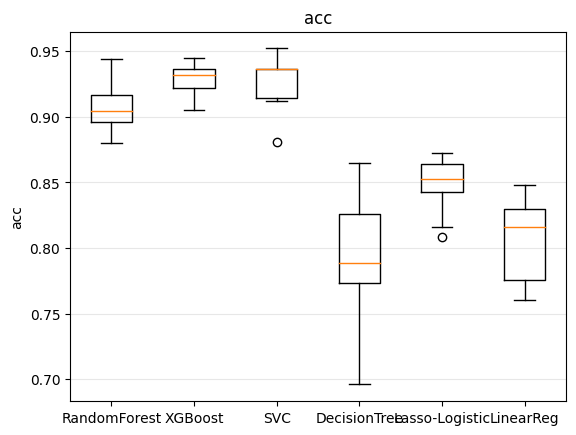

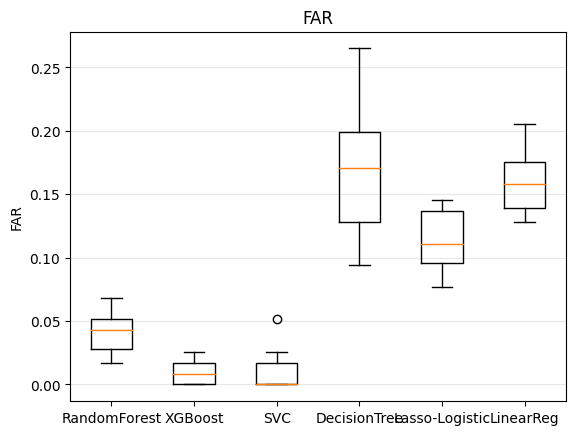

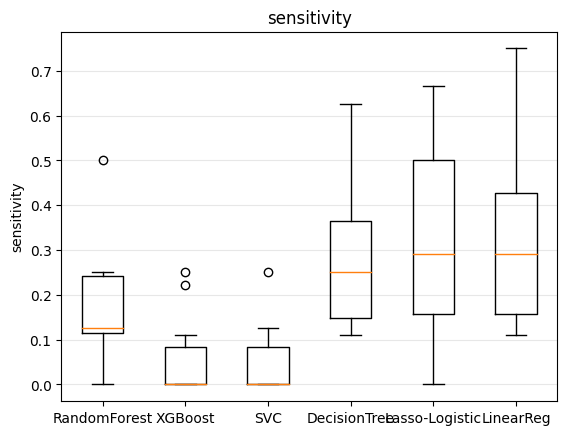

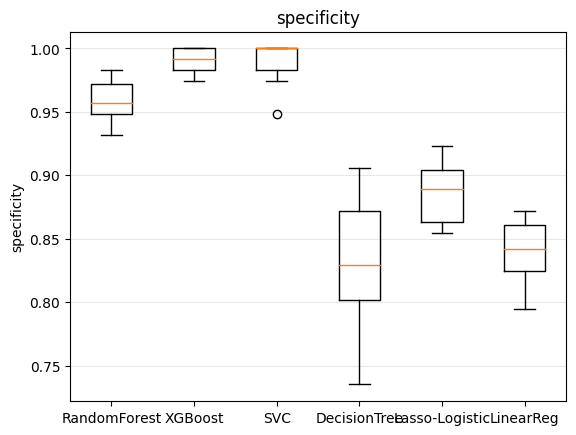

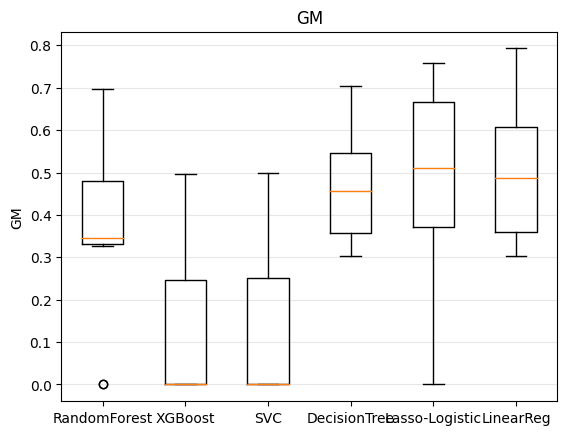

In [16]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

METRICS = ['acc','FAR','sensitivity','specificity','GM']

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append({'model':model_name,'fold':fold, **{k:m[k] for k in METRICS}})
    df = pd.DataFrame(fold_metrics)
    avg = {k: df[k].mean() for k in METRICS}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}")
    return avg, df

imp = SimpleImputer(strategy='median')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)

svc_pipe = Pipeline(steps=[('impute', imp),
                           ('scaler', StandardScaler()),
                           ('smote', smote),
                           ('svc', SVC(kernel='rbf', C=1.0, gamma='auto', class_weight='balanced', random_state=42))])

xgb_pipe = Pipeline(steps=[('impute', imp),
                           ('smote', smote),
                           ('clf', XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, tree_method='hist'))])

lasso_logit_pipe = Pipeline(steps=[('impute', imp),
                                   ('scaler', StandardScaler()),
                                   ('smote', smote),
                                   ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, random_state=42))])

rfc_pipe = Pipeline(steps=[('impute', imp),
                          ('smote', smote),
                          ('clf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, class_weight='balanced', random_state=42, n_jobs=-1))])

dt_pipe = Pipeline(steps=[('impute', imp),
                          ('smote', smote),
                          ('clf', DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'))])

linr_pipe = Pipeline(steps=[('impute', imp),
                            ('scaler',StandardScaler()),
                            ('smote', smote),
                            ('clf', LinearRegression())])

models = [('RandomForest', rfc_pipe), ("XGBoost", xgb_pipe), ('SVC', svc_pipe), ("DecisionTree", dt_pipe), ("Lasso-Logistic", lasso_logit_pipe), ("LinearReg", linr_pipe)]

all_avg, fold_dfs = {}, []
for name, pipe in models:
    avg, df = run_cv(name, pipe, skf, X_train, y_train)
    all_avg[name] = avg
    fold_dfs.append(df)

cv_df = pd.concat(fold_dfs, ignore_index=True)  # 欄位：model, fold, acc, FAR, sensitivity, specificity, GM

# 盒鬚圖
for metric in METRICS:
    plt.figure()
    data = [cv_df.loc[cv_df['model']==m, metric].values for m,_ in models]
    labels = [m for m,_ in models]
    plt.boxplot(data, labels=labels, showfliers=True)
    plt.ylabel(metric); plt.title(f'{metric}')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()



---
### 所有機器學習模型的10折結果, 不作特徵選擇, KNN補值
| Model              |   ACC  |   FAR  | Sensitivity | Specificity |   GM   |
| :----------------- | :----: | :----: | :---------: | :---------: | :----: |
| **RandomForest**   | 0.9091 | 0.0419 |    0.2194   |    0.9581   | 0.3998 |
| **XGBoost**        | 0.9258 | 0.0111 |    0.0347   |    0.9889   | 0.0820 |
| **SVC**            | 0.9266 | 0.0111 |    0.0486   |    0.9889   | 0.1187 |
| **DecisionTree**   | 0.8093 | 0.1564 |    0.3264   |    0.8436   | 0.5108 |
| **Lasso-Logistic** | 0.8396 | 0.1214 |    0.2903   |    0.8786   | 0.4662 |
| **LinearReg**      | 0.8069 | 0.1632 |    0.3861   |    0.8368   | 0.5495 |



[RandomForest] MEAN acc=0.9091 FAR=0.0419 sens=0.2194 spec=0.9581 GM=0.3998
[XGBoost] MEAN acc=0.9258 FAR=0.0111 sens=0.0347 spec=0.9889 GM=0.0820
[SVC] MEAN acc=0.9266 FAR=0.0111 sens=0.0486 spec=0.9889 GM=0.1187
[DecisionTree] MEAN acc=0.8093 FAR=0.1564 sens=0.3264 spec=0.8436 GM=0.5108
[Lasso-Logistic] MEAN acc=0.8396 FAR=0.1214 sens=0.2903 spec=0.8786 GM=0.4662
[LinearReg] MEAN acc=0.8069 FAR=0.1632 sens=0.3861 spec=0.8368 GM=0.5495


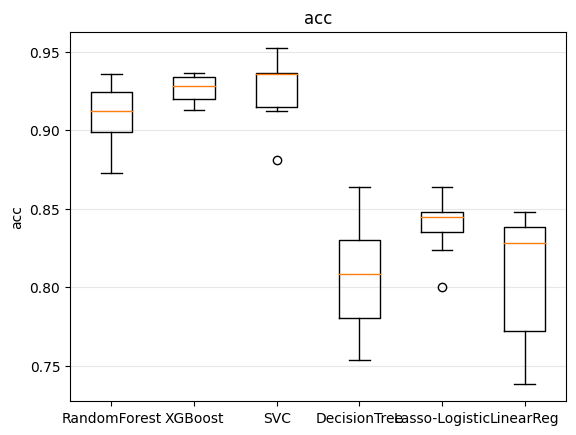

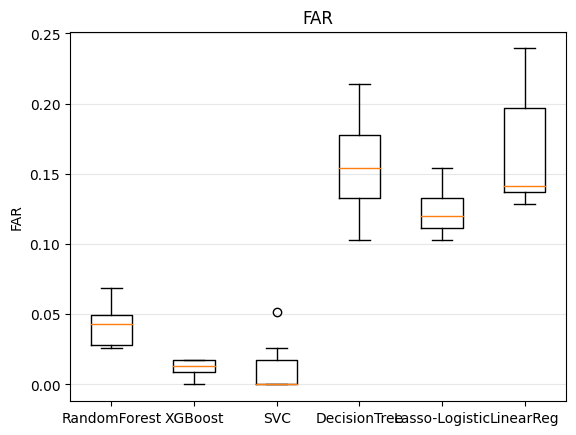

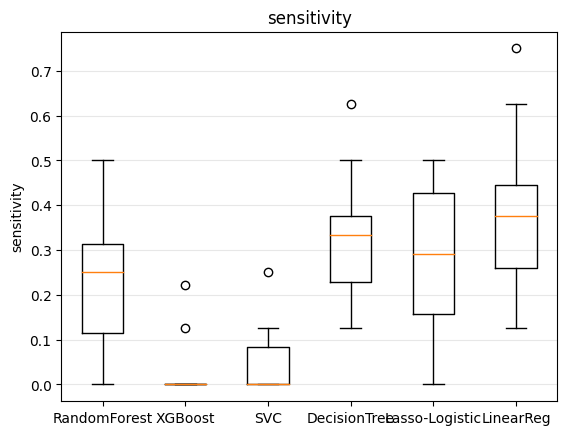

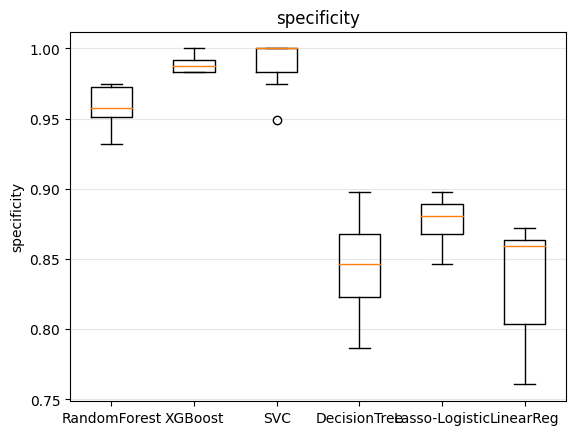

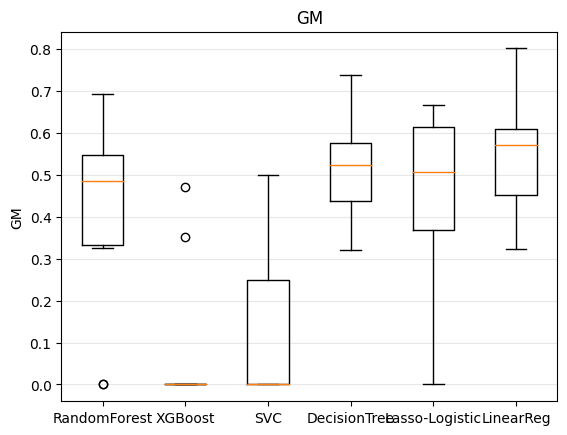

In [17]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

METRICS = ['acc','FAR','sensitivity','specificity','GM']

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append({'model':model_name,'fold':fold, **{k:m[k] for k in METRICS}})
    df = pd.DataFrame(fold_metrics)
    avg = {k: df[k].mean() for k in METRICS}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}")
    return avg, df

knn = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)

svc_pipe = Pipeline(steps=[('impute', imp),
                           ('scaler', StandardScaler()),
                           ('smote', smote),
                           ('svc', SVC(kernel='rbf', C=1.0, gamma='auto', class_weight='balanced', random_state=42))])

xgb_pipe = Pipeline(steps=[('impute', knn),
                           ('smote', smote),
                           ('clf', XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, tree_method='hist'))])

lasso_logit_pipe = Pipeline(steps=[('impute', knn),
                                   ('scaler', StandardScaler()),
                                   ('smote', smote),
                                   ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, random_state=42))])

rfc_pipe = Pipeline(steps=[('impute', knn),
                          ('smote', smote),
                          ('clf', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, class_weight='balanced', random_state=42, n_jobs=-1))])

dt_pipe = Pipeline(steps=[('impute', knn),
                          ('smote', smote),
                          ('clf', DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'))])

linr_pipe = Pipeline(steps=[('impute', knn),
                            ('scaler',StandardScaler()),
                            ('smote', smote),
                            ('clf', LinearRegression())])

models = [('RandomForest', rfc_pipe), ("XGBoost", xgb_pipe), ('SVC', svc_pipe), ("DecisionTree", dt_pipe), ("Lasso-Logistic", lasso_logit_pipe), ("LinearReg", linr_pipe)]

all_avg, fold_dfs = {}, []
for name, pipe in models:
    avg, df = run_cv(name, pipe, skf, X_train, y_train)
    all_avg[name] = avg
    fold_dfs.append(df)

cv_df = pd.concat(fold_dfs, ignore_index=True)  # 欄位：model, fold, acc, FAR, sensitivity, specificity, GM

# 盒鬚圖
for metric in METRICS:
    plt.figure()
    data = [cv_df.loc[cv_df['model']==m, metric].values for m,_ in models]
    labels = [m for m,_ in models]
    plt.boxplot(data, labels=labels, showfliers=True)
    plt.ylabel(metric); plt.title(f'{metric}')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()


---
---

### 0.2測試 0.8訓練再拆成0.2驗證 0.8訓練 做10折訓練, 每折先做隨機森林特徵篩選, KNN補值, SMOTE過度抽樣, 決策樹訓練後, 再用驗證取最佳的k, 取得被取到10次的features來做最後的測試

In [ ]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

knn_imp = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, random_state=42, k_neighbors=5)

rf_ = dict(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
dt_ = dict(random_state=42, class_weight='balanced', max_depth=6)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

def candidate_k_list(p, m=12):
    m = min(m, p)
    ks = np.unique(np.linspace(min(10, p), p, num=m, dtype=int))
    ks = ks[ks > 0]
    return ks

best_k_per_fold = []
features_per_fold = []
feature_pick_counter = Counter()

for fold_id, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    
    rf = RandomForestClassifier(**rf_)
    rf.fit(X_tr, y_tr)

    importances = pd.Series(rf.feature_importances_, index=X_tr.columns)
    order = importances.sort_values(ascending=False).index.tolist()

    # 針對不同前 k 個特徵：KNN 補值（只用訓練 fit）、決策樹在 valid 算 acc，取最佳 k
    ks = candidate_k_list(p=len(order), m=12)
    best_acc, best_k, best_feats = -1.0, None, None

    for k in ks:
        sel = order[:k]

        X_tr_sel_imp = pd.DataFrame(knn_imp.fit_transform(X_tr[sel]), columns=sel, index=X_tr.index)
        X_va_sel_imp = pd.DataFrame(knn_imp.transform(X_va[sel]), columns=sel, index=X_va.index)

        X_tr_res, y_tr_res = smote.fit_resample(X_tr_sel_imp, y_tr)

        clf = DecisionTreeClassifier(**dt_)
        clf.fit(X_tr_res, y_tr_res)
        va_pred = clf.predict(X_va_sel_imp)
        acc = accuracy_score(y_va, va_pred)

        if acc > best_acc:
            best_acc, best_k, best_feats = acc, k, sel

    best_k_per_fold.append((fold_id, best_k, best_acc))
    features_per_fold.append((fold_id, best_feats))
    feature_pick_counter.update(best_feats)

# ---- 輸出 ----
print("每折最佳 k 與驗證集 accuracy：")
for fid, bk, ba in best_k_per_fold:
    print(f"[Fold {fid:02d}] best_k={bk:<4d}  valid_acc={ba:.4f}")

feat_counts_df = pd.DataFrame(feature_pick_counter.most_common(), columns=['feature', 'selected_count'])

top = feat_counts_df[feat_counts_df['selected_count']==10]['feature'].tolist()

Xtr_imp = pd.DataFrame(knn_imp.fit_transform(X_train[top]), columns=top, index=X_train.index)
Xte_imp = pd.DataFrame(knn_imp.transform(X_test[top]), columns=top, index=X_test.index)

clf = DecisionTreeClassifier(**dt_)
clf.fit(Xtr_imp, y_train)
yhat = clf.predict(Xte_imp)

res = compute_metrics(y_test, yhat)
print(f"[TEST] acc={res['acc']:.4f} FAR={res['FAR']:.4f} sens={res['sensitivity']:.4f} spec={res['specificity']:.4f} GM={res['GM']:.4f}")
print(res['cm'])

每折最佳 k 與驗證集 accuracy：
[Fold 01] best_k=168   valid_acc=0.8333
[Fold 02] best_k=327   valid_acc=0.8333
[Fold 03] best_k=447   valid_acc=0.8254
[Fold 04] best_k=407   valid_acc=0.9040
[Fold 05] best_k=248   valid_acc=0.9120
[Fold 06] best_k=10    valid_acc=0.8320
[Fold 07] best_k=129   valid_acc=0.8720
[Fold 08] best_k=367   valid_acc=0.9280
[Fold 09] best_k=447   valid_acc=0.8480
[Fold 10] best_k=407   valid_acc=0.8240
[TEST] acc=0.8248 FAR=0.1399 sens=0.3333 spec=0.8601 GM=0.5354
[[252  41]
 [ 14   7]]


In [26]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

knn_imp = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, random_state=42, k_neighbors=5)

rf_ = dict(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
dt_ = dict(random_state=42, class_weight='balanced', max_depth=6)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

def candidate_k_list(p, m=12):
    m = min(m, p)
    ks = np.unique(np.linspace(min(10, p), p, num=m, dtype=int))
    ks = ks[ks > 0]
    return ks

best_k_per_fold = []
features_per_fold = []
feature_pick_counter = Counter()

for fold_id, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    
    rf = RandomForestClassifier(**rf_)
    rf.fit(X_tr, y_tr)

    importances = pd.Series(rf.feature_importances_, index=X_tr.columns)
    order = importances.sort_values(ascending=False).index.tolist()

    # 針對不同前 k 個特徵：KNN 補值（只用訓練 fit）、決策樹在 valid 算 acc，取最佳 k
    ks = candidate_k_list(p=len(order), m=12)
    best_acc, best_k, best_feats = -1.0, None, None

    for k in ks:
        sel = order[:k]

        X_tr_sel_imp = pd.DataFrame(knn_imp.fit_transform(X_tr[sel]), columns=sel, index=X_tr.index)
        X_va_sel_imp = pd.DataFrame(knn_imp.transform(X_va[sel]), columns=sel, index=X_va.index)

        X_tr_res, y_tr_res = smote.fit_resample(X_tr_sel_imp, y_tr)

        clf = DecisionTreeClassifier(**dt_)
        clf.fit(X_tr_res, y_tr_res)
        va_pred = clf.predict(X_va_sel_imp)
        acc = accuracy_score(y_va, va_pred)

        if acc > best_acc:
            best_acc, best_k, best_feats = acc, k, sel

    best_k_per_fold.append((fold_id, best_k, best_acc))
    features_per_fold.append((fold_id, best_feats))
    feature_pick_counter.update(best_feats)

# ---- 輸出 ----
print("每折最佳 k 與驗證集 accuracy：")
for fid, bk, ba in best_k_per_fold:
    print(f"[Fold {fid:02d}] best_k={bk:<4d}  valid_acc={ba:.4f}")

feat_counts_df = pd.DataFrame(feature_pick_counter.most_common(), columns=['feature', 'selected_count'])

top = feat_counts_df[feat_counts_df['selected_count']==10]['feature'].tolist()

Xtr_imp = pd.DataFrame(knn_imp.fit_transform(X_train[top]), columns=top, index=X_train.index)
Xte_imp = pd.DataFrame(knn_imp.transform(X_test[top]), columns=top, index=X_test.index)
Xtr_imp_res, y_train_res = smote.fit_resample(Xtr_imp, y_train)
clf = DecisionTreeClassifier(**dt_)
clf.fit(Xtr_imp_res, y_train_res)
yhat = clf.predict(Xte_imp)

res = compute_metrics(y_test, yhat)
print(f"[TEST] acc={res['acc']:.4f} FAR={res['FAR']:.4f} sens={res['sensitivity']:.4f} spec={res['specificity']:.4f} GM={res['GM']:.4f}")
print(res['cm'])

每折最佳 k 與驗證集 accuracy：
[Fold 01] best_k=168   valid_acc=0.8333
[Fold 02] best_k=327   valid_acc=0.8333
[Fold 03] best_k=447   valid_acc=0.8254
[Fold 04] best_k=407   valid_acc=0.9040
[Fold 05] best_k=248   valid_acc=0.9120
[Fold 06] best_k=10    valid_acc=0.8320
[Fold 07] best_k=129   valid_acc=0.8720
[Fold 08] best_k=367   valid_acc=0.9280
[Fold 09] best_k=447   valid_acc=0.8480
[Fold 10] best_k=407   valid_acc=0.8240
[TEST] acc=0.7134 FAR=0.2867 sens=0.7143 spec=0.7133 GM=0.7138
[[209  84]
 [  6  15]]


In [24]:
feat_counts_df['selected_count'].value_counts()

selected_count
9     91
8     71
5     71
6     69
7     68
4     39
2     15
3     13
10    10
Name: count, dtype: int64

In [25]:
# --- 使用被選滿10次的 features 在原始資料做 10-fold CV（KNN→SMOTE→DT） ---
if len(top) == 0:
    print("[CV-ON-ORIG] 沒有滿10次的特徵，請放寬門檻（例如 >=8）或改取前N名。")
else:
    cv2 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    fold_metrics = []
    for fid, (tr_idx, va_idx) in enumerate(cv2.split(X[top], y), 1):
        X_tr_raw, X_va_raw = X.iloc[tr_idx][top], X.iloc[va_idx][top]
        y_tr, y_va       = y.iloc[tr_idx], y.iloc[va_idx]

        # 前處理：KNN（fit on train → transform valid）
        knn_imp2 = KNNImputer(n_neighbors=10, weights='distance')
        X_tr_imp = pd.DataFrame(knn_imp2.fit_transform(X_tr_raw), columns=top, index=X_tr_raw.index)
        X_va_imp = pd.DataFrame(knn_imp2.transform(X_va_raw),     columns=top, index=X_va_raw.index)

        # SMOTE：只對訓練集
        smote2 = SMOTE(sampling_strategy=1.0, random_state=42, k_neighbors=5)
        X_tr_res, y_tr_res = smote2.fit_resample(X_tr_imp, y_tr)

        # 決策樹訓練與驗證
        clf2 = DecisionTreeClassifier(**dt_)
        clf2.fit(X_tr_res, y_tr_res)
        y_va_pred = clf2.predict(X_va_imp)

        fold_res = compute_metrics(y_va, y_va_pred)
        fold_metrics.append(fold_res)
        print(f"[CV-ON-ORIG Fold {fid:02d}] acc={fold_res['acc']:.4f} "
              f"FAR={fold_res['FAR']:.4f} sens={fold_res['sensitivity']:.4f} "
              f"spec={fold_res['specificity']:.4f} GM={fold_res['GM']:.4f}")

    # 平均成績
    def _m(key): 
        vals = [m[key] for m in fold_metrics if not np.isnan(m[key])]
        return np.mean(vals) if len(vals)>0 else np.nan
    print(f"[CV-ON-ORIG MEAN] acc={_m('acc'):.4f} FAR={_m('FAR'):.4f} "
          f"sens={_m('sensitivity'):.4f} spec={_m('specificity'):.4f} GM={_m('GM'):.4f}")


[CV-ON-ORIG Fold 01] acc=0.8344 FAR=0.1565 sens=0.7000 spec=0.8435 GM=0.7684
[CV-ON-ORIG Fold 02] acc=0.7643 FAR=0.2041 sens=0.3000 spec=0.7959 GM=0.4886
[CV-ON-ORIG Fold 03] acc=0.7389 FAR=0.2449 sens=0.5000 spec=0.7551 GM=0.6145
[CV-ON-ORIG Fold 04] acc=0.8025 FAR=0.1644 sens=0.3636 spec=0.8356 GM=0.5512
[CV-ON-ORIG Fold 05] acc=0.7898 FAR=0.1849 sens=0.4545 spec=0.8151 GM=0.6087
[CV-ON-ORIG Fold 06] acc=0.8344 FAR=0.1438 sens=0.5455 spec=0.8562 GM=0.6834
[CV-ON-ORIG Fold 07] acc=0.5350 FAR=0.4658 sens=0.5455 spec=0.5342 GM=0.5398
[CV-ON-ORIG Fold 08] acc=0.8077 FAR=0.1644 sens=0.4000 spec=0.8356 GM=0.5781
[CV-ON-ORIG Fold 09] acc=0.7885 FAR=0.1781 sens=0.3000 spec=0.8219 GM=0.4966
[CV-ON-ORIG Fold 10] acc=0.7244 FAR=0.2603 sens=0.5000 spec=0.7397 GM=0.6082
[CV-ON-ORIG MEAN] acc=0.7620 FAR=0.2167 sens=0.4609 spec=0.7833 GM=0.5937


In [7]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf_ = dict(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
knn_imp = KNNImputer(n_neighbors=10, weights='distance')
svc_ = dict(kernel='rbf', C=1.0, gamma='auto', class_weight='balanced', random_state=42)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

def candidate_k_list(p, m=12):
    m = min(m, p)
    ks = np.unique(np.linspace(min(10, p), p, num=m, dtype=int))
    ks = ks[ks > 0]
    return ks

best_k_per_fold = []
features_per_fold = []
feature_pick_counter = Counter()

for fold_id, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    rf = RandomForestClassifier(**rf_)
    rf.fit(X_tr, y_tr)

    importances = pd.Series(rf.feature_importances_, index=X_tr.columns)
    order = importances.sort_values(ascending=False).index.tolist()

    # 針對不同前 k 個特徵：KNN 補值（只用訓練 fit）、決策樹在 valid 算 acc，取最佳 k
    ks = candidate_k_list(p=len(order), m=12)
    best_acc, best_k, best_feats = -1.0, None, None

    for k in ks:
        sel = order[:k]

        X_tr_sel_imp = pd.DataFrame(knn_imp.fit_transform(X_tr[sel]), columns=sel, index=X_tr.index)
        X_va_sel_imp = pd.DataFrame(knn_imp.transform(X_va[sel]), columns=sel, index=X_va.index)

        scaler = StandardScaler()
        X_tr_sel_std = pd.DataFrame(scaler.fit_transform(X_tr_sel_imp), columns=sel, index=X_tr.index)
        X_va_sel_std = pd.DataFrame(scaler.transform(X_va_sel_imp),     columns=sel, index=X_va.index)

        svc = SVC(**svc_)
        svc.fit(X_tr_sel_std, y_tr)
        va_pred = svc.predict(X_va_sel_std)
        acc = accuracy_score(y_va, va_pred)

        if acc > best_acc:
            best_acc, best_k, best_feats = acc, k, sel

    best_k_per_fold.append((fold_id, best_k, best_acc))
    features_per_fold.append((fold_id, best_feats))
    feature_pick_counter.update(best_feats)

# ---- 輸出 ----
print("每折最佳 k 與驗證集 accuracy：")
for fid, bk, ba in best_k_per_fold:
    print(f"[Fold {fid:02d}] best_k={bk:<4d}  valid_acc={ba:.4f}")

feat_counts_df = pd.DataFrame(feature_pick_counter.most_common(), columns=['feature', 'selected_count'])

top = feat_counts_df[feat_counts_df['selected_count']==10]['feature'].tolist()

Xtr_imp = pd.DataFrame(knn_imp.fit_transform(X_train[top]), columns=top, index=X_train.index)
Xte_imp = pd.DataFrame(knn_imp.transform(X_test[top]), columns=top, index=X_test.index)

scaler = StandardScaler()
Xtr_std = pd.DataFrame(scaler.fit_transform(Xtr_imp), columns=top, index=X_train.index)
Xte_std = pd.DataFrame(scaler.transform(Xte_imp),     columns=top, index=X_test.index)

svc = SVC(**svc_)  # 與前述相同：gini, max_depth=6, class_weight='balanced', random_state=42
svc.fit(Xtr_std, y_train)
yhat = svc.predict(Xte_std)

res = compute_metrics(y_test, yhat)
print(f"[TEST] acc={res['acc']:.4f} FAR={res['FAR']:.4f} sens={res['sensitivity']:.4f} spec={res['specificity']:.4f} GM={res['GM']:.4f}")
print(res['cm'])

每折最佳 k 與驗證集 accuracy：
[Fold 01] best_k=447   valid_acc=0.9206
[Fold 02] best_k=129   valid_acc=0.9524
[Fold 03] best_k=248   valid_acc=0.8651
[Fold 04] best_k=168   valid_acc=0.9360
[Fold 05] best_k=208   valid_acc=0.9360
[Fold 06] best_k=407   valid_acc=0.9440
[Fold 07] best_k=367   valid_acc=0.9280
[Fold 08] best_k=288   valid_acc=0.9360
[Fold 09] best_k=447   valid_acc=0.9440
[Fold 10] best_k=327   valid_acc=0.9120
[TEST] acc=0.8917 FAR=0.0580 sens=0.1905 spec=0.9420 GM=0.4236
[[276  17]
 [ 17   4]]


In [10]:
feat_counts_df['selected_count'].value_counts()

selected_count
10    92
5     59
9     56
6     55
4     49
8     47
7     42
3     27
2     20
Name: count, dtype: int64

In [6]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf_ = dict(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
knn_imp = KNNImputer(n_neighbors=10, weights='distance')
xgb_ = dict(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, tree_method='hist', eval_metric='logloss')

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

def candidate_k_list(p, m=12):
    m = min(m, p)
    ks = np.unique(np.linspace(min(10, p), p, num=m, dtype=int))
    ks = ks[ks > 0]
    return ks

best_k_per_fold = []
features_per_fold = []
feature_pick_counter = Counter()

for fold_id, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    rf = RandomForestClassifier(**rf_)
    rf.fit(X_tr, y_tr)

    importances = pd.Series(rf.feature_importances_, index=X_tr.columns)
    order = importances.sort_values(ascending=False).index.tolist()

    # 針對不同前 k 個特徵：KNN 補值（只用訓練 fit）、決策樹在 valid 算 acc，取最佳 k
    ks = candidate_k_list(p=len(order), m=12)
    best_acc, best_k, best_feats = -1.0, None, None

    for k in ks:
        sel = order[:k]

        X_tr_sel_imp = pd.DataFrame(knn_imp.fit_transform(X_tr[sel]), columns=sel, index=X_tr.index)
        X_va_sel_imp = pd.DataFrame(knn_imp.transform(X_va[sel]), columns=sel, index=X_va.index)

        xgb = XGBClassifier(**xgb_)
        xgb.fit(X_tr_sel_imp, y_tr)
        va_pred = xgb.predict(X_va_sel_imp)
        acc = accuracy_score(y_va, va_pred)

        if acc > best_acc:
            best_acc, best_k, best_feats = acc, k, sel

    best_k_per_fold.append((fold_id, best_k, best_acc))
    features_per_fold.append((fold_id, best_feats))
    feature_pick_counter.update(best_feats)

# ---- 輸出 ----
print("每折最佳 k 與驗證集 accuracy：")
for fid, bk, ba in best_k_per_fold:
    print(f"[Fold {fid:02d}] best_k={bk:<4d}  valid_acc={ba:.4f}")

feat_counts_df = pd.DataFrame(feature_pick_counter.most_common(), columns=['feature', 'selected_count'])

top = feat_counts_df[feat_counts_df['selected_count']==10]['feature'].tolist()

Xtr_imp = pd.DataFrame(knn_imp.fit_transform(X_train[top]), columns=top, index=X_train.index)
Xte_imp = pd.DataFrame(knn_imp.transform(X_test[top]), columns=top, index=X_test.index)

xgb = XGBClassifier(**xgb_)  # 與前述相同：gini, max_depth=6, class_weight='balanced', random_state=42
xgb.fit(Xtr_imp, y_train)
yhat = xgb.predict(Xte_imp)

res = compute_metrics(y_test, yhat)
print(f"[TEST] acc={res['acc']:.4f} FAR={res['FAR']:.4f} sens={res['sensitivity']:.4f} spec={res['specificity']:.4f} GM={res['GM']:.4f}")
print(res['cm'])

每折最佳 k 與驗證集 accuracy：
[Fold 01] best_k=10    valid_acc=0.9286
[Fold 02] best_k=129   valid_acc=0.9444
[Fold 03] best_k=89    valid_acc=0.9286
[Fold 04] best_k=10    valid_acc=0.9440
[Fold 05] best_k=10    valid_acc=0.9360
[Fold 06] best_k=49    valid_acc=0.9520
[Fold 07] best_k=10    valid_acc=0.9360
[Fold 08] best_k=10    valid_acc=0.9360
[Fold 09] best_k=10    valid_acc=0.9360
[Fold 10] best_k=89    valid_acc=0.9360
[TEST] acc=0.9331 FAR=0.0034 sens=0.0476 spec=0.9966 GM=0.2178
[[292   1]
 [ 20   1]]
